<a href="https://colab.research.google.com/github/aarya078/July26/blob/main/BlackFriday.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("BlackFriday.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69255 entries, 0 to 69254
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     69255 non-null  int64  
 1   Product_ID                  69255 non-null  object 
 2   Gender                      69255 non-null  object 
 3   Age                         69255 non-null  object 
 4   Occupation                  69255 non-null  int64  
 5   City_Category               69255 non-null  object 
 6   Stay_In_Current_City_Years  69255 non-null  object 
 7   Marital_Status              69255 non-null  int64  
 8   Product_Category_1          69255 non-null  int64  
 9   Product_Category_2          47538 non-null  float64
 10  Product_Category_3          21067 non-null  float64
 11  Purchase                    69254 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 6.3+ MB


In [4]:
df.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,21717


In [5]:
df.dropna()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
6,1000004,P00184942,M,46-50,7,B,2,1,1,8.0,17.0,19215.0
13,1000005,P00145042,M,26-35,20,A,1,1,1,2.0,5.0,15665.0
14,1000006,P00231342,F,51-55,9,A,1,0,5,8.0,14.0,5378.0
16,1000006,P0096642,F,51-55,9,A,1,0,2,3.0,4.0,13055.0
...,...,...,...,...,...,...,...,...,...,...,...,...
69210,1004578,P00105142,M,26-35,0,A,4+,0,1,2.0,15.0,19699.0
69216,1004578,P00050442,M,26-35,0,A,4+,0,1,8.0,13.0,15688.0
69217,1004578,P00112642,M,26-35,0,A,4+,0,1,2.0,5.0,15530.0
69220,1004578,P00002242,M,26-35,0,A,4+,0,6,8.0,16.0,16086.0


In [6]:
del df['Product_Category_2']
del df['Product_Category_3']
#since these contain many null values so removing them

In [7]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969.0
...,...,...,...,...,...,...,...,...,...,...
69250,1004581,P00315842,M,26-35,1,C,2,1,5,1971.0
69251,1004581,P00118742,M,26-35,1,C,2,1,5,8867.0
69252,1004581,P00120342,M,26-35,1,C,2,1,5,5183.0
69253,1004581,P00114442,M,26-35,1,C,2,1,5,6912.0


FINDING UNIQUE VALUES IN EACH COLUMN

In [9]:
df['User_ID'].unique()


array([1000001, 1000002, 1000003, ..., 1004554, 1004559, 1004564])

In [10]:
df['Age'].unique()


array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [11]:
df['Product_ID'].unique()


array(['P00069042', 'P00248942', 'P00087842', ..., 'P00131842',
       'P00257242', 'P00306542'], dtype=object)

In [12]:
df['Occupation'].unique()


array([10, 16, 15,  7, 20,  9,  1, 12, 17,  0,  3,  4, 11,  8, 19,  2, 18,
        5, 14, 13,  6])

In [13]:
df['City_Category'].unique()


array(['A', 'C', 'B'], dtype=object)

In [14]:
df['Marital_Status'].unique()

array([0, 1])

In [15]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [16]:
df['Gender'].unique()

array(['F', 'M'], dtype=object)

<Axes: ylabel='Ratio'>

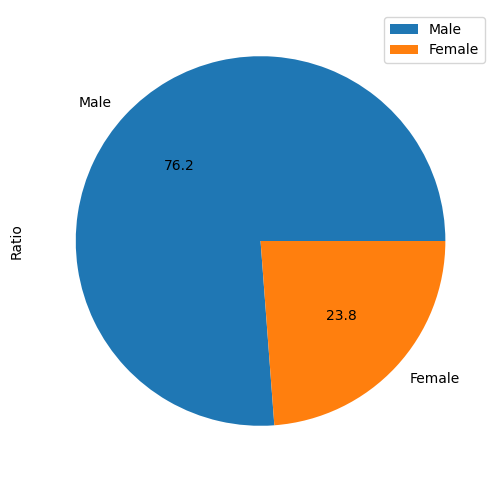

In [18]:
data = pd.DataFrame({'Ratio' : [len(df[df['Gender'] == 'M']) , len(df[df['Gender'] == 'F'])]} , index = ['Male' , 'Female'])
data.plot.pie(y = 'Ratio' , figsize = (6,6), autopct = "%.1f")

<Axes: xlabel='Gender'>

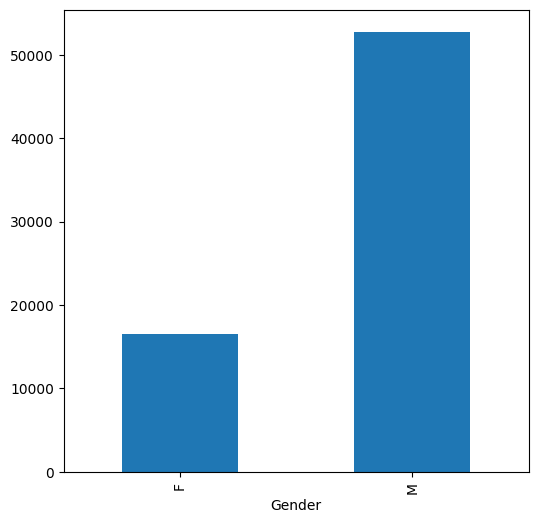

In [19]:
df.groupby('Gender').size().plot(kind = 'bar', figsize = (6,6))

In [21]:
df.groupby('Gender').size()

,0
Gender,
F,16490
M,52765


AGE

<Axes: title={'center': 'Purchase Distribution by AGE'}, xlabel='Age'>

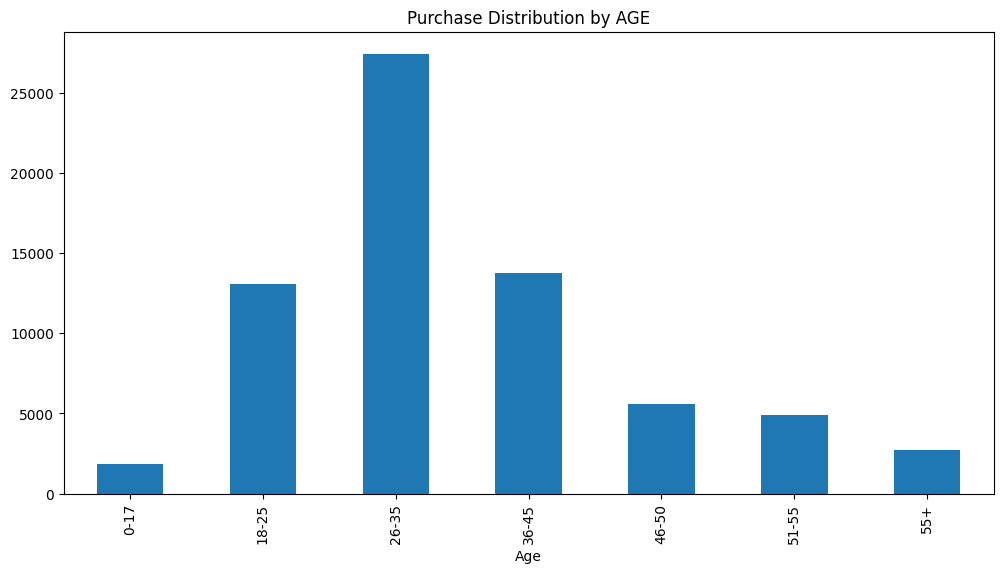

In [22]:
df.groupby('Age').size().plot(kind= 'bar', figsize = (12,6), title = 'Purchase Distribution by AGE')


In [23]:
data = df.groupby('Age')['Product_ID'].nunique().reset_index()
data.columns = ['Age','Products']

<Axes: xlabel='Age'>

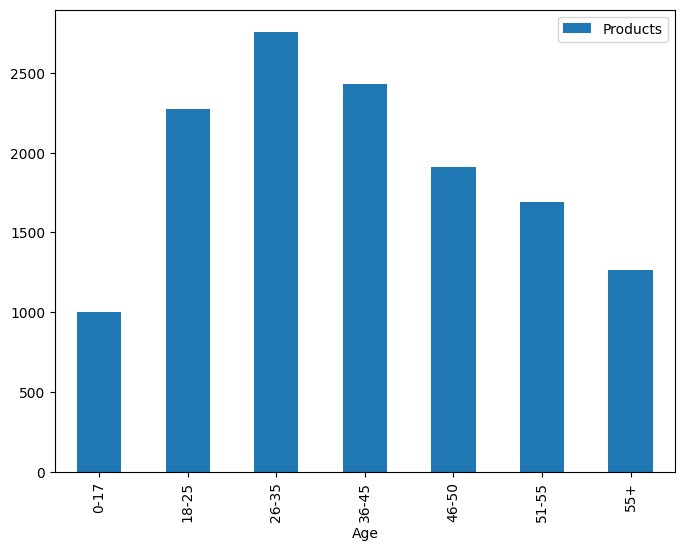

In [24]:
data.plot.bar( x = 'Age' , figsize = (8,6))

<Axes: title={'center': 'Amount spent by age'}, xlabel='Age'>

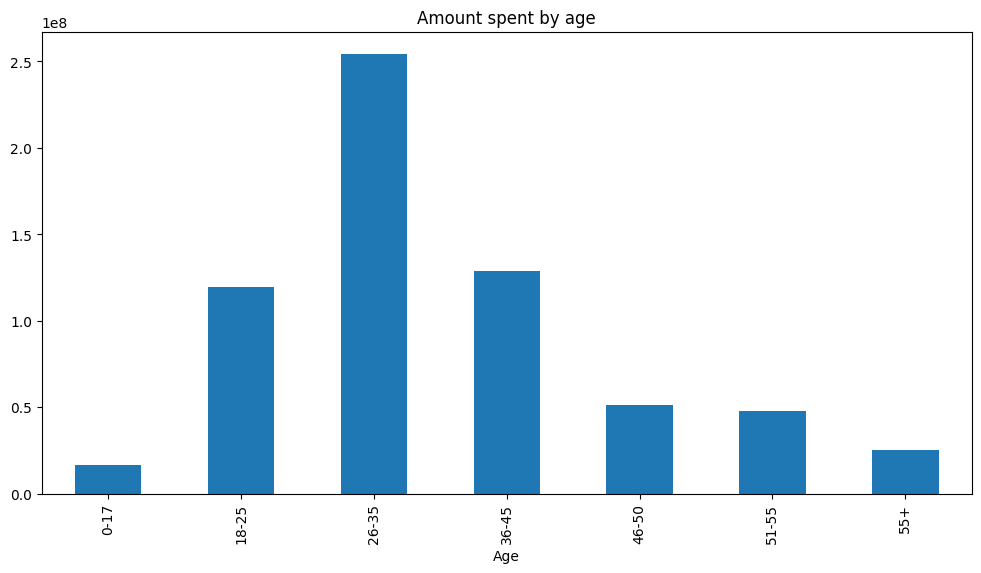

In [25]:
df.groupby('Age').sum()['Purchase'].plot(kind = 'bar', figsize = (12,6), title = 'Amount spent by age')

<Axes: title={'center': 'Amount spent by age'}, xlabel='Age'>

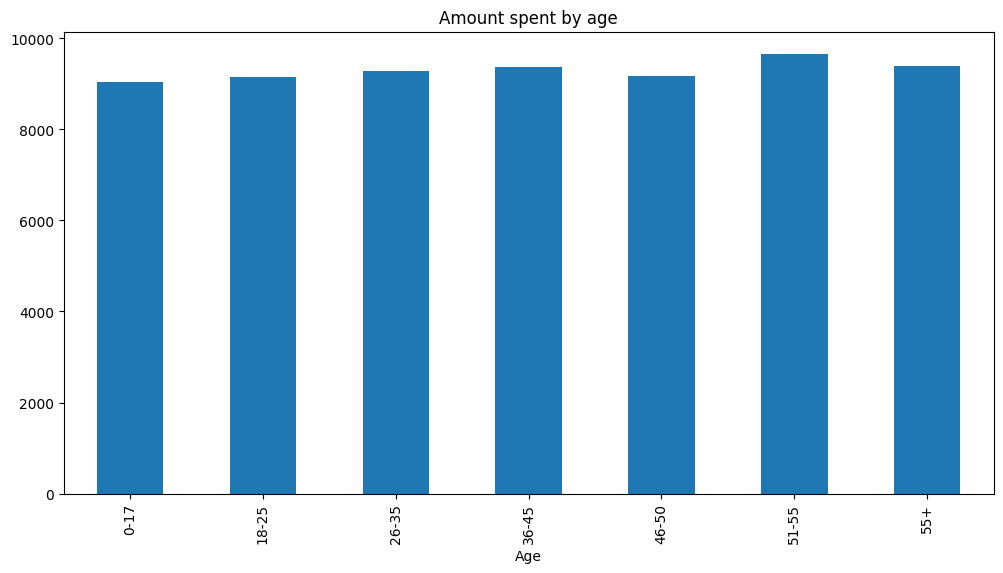

In [26]:
df.groupby('Age')['Purchase'].mean().plot(kind = 'bar' , figsize = (12,6) , title = 'Amount spent by age')

<Axes: ylabel='Purchase'>

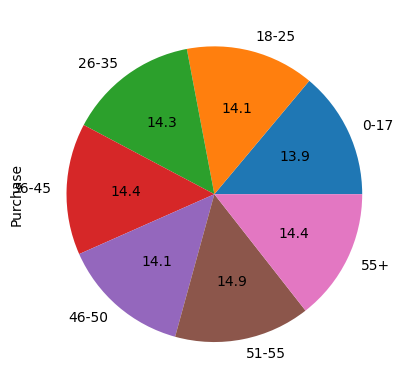

In [31]:
df.groupby('Age')['Purchase'].mean().plot(kind ='pie', autopct ='%0.1f')

<Axes: >

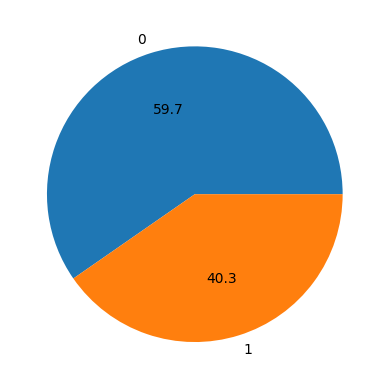

In [33]:
df.groupby('Marital_Status').size().plot(kind = 'pie', autopct = '%0.1f')

<Axes: title={'center': 'Purchase age distribution by agae'}, xlabel='Age'>

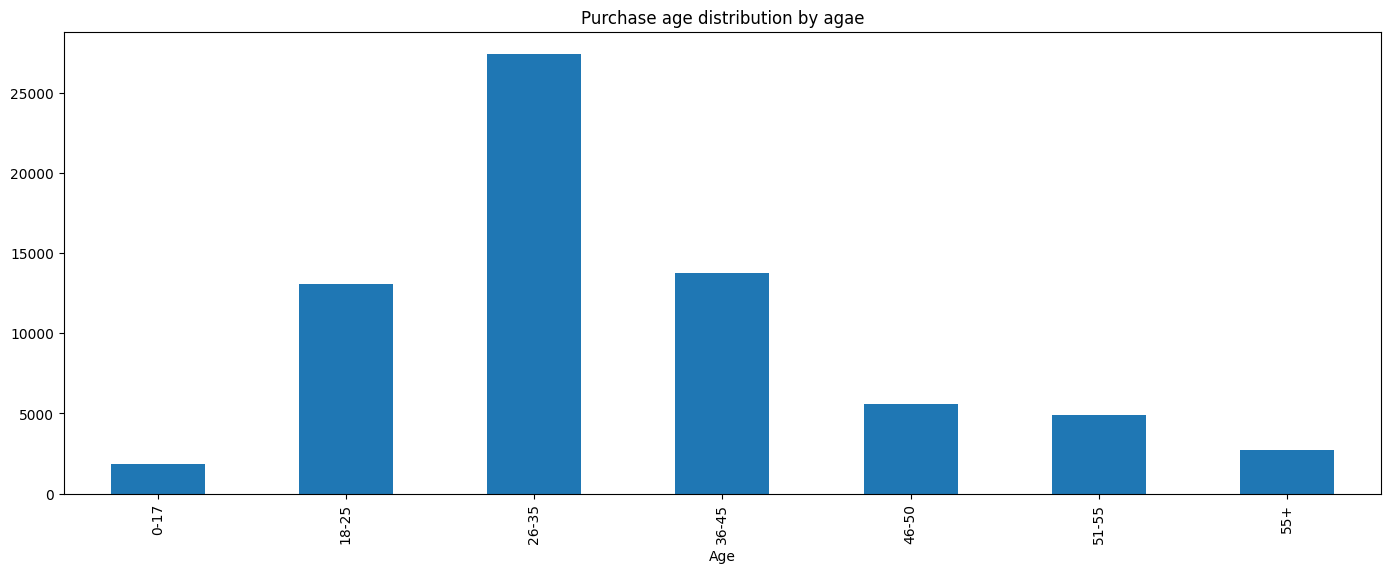

In [34]:
df.groupby('Age').size().plot(kind= 'bar', figsize= (17,6), title = "Purchase age distribution by agae")

<Axes: xlabel='Gender', ylabel='count'>

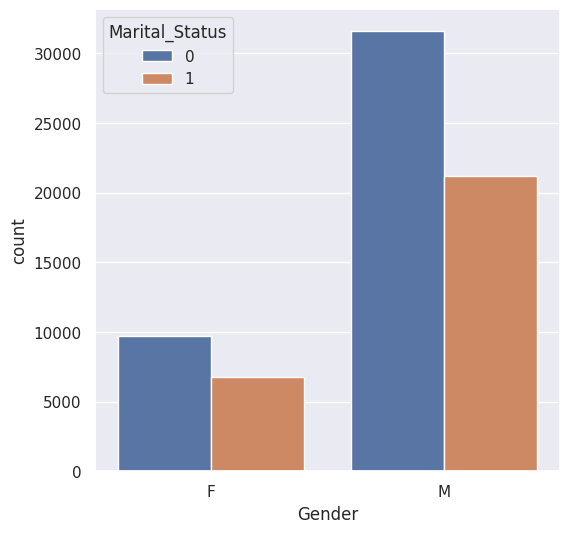

In [36]:
sns.set(rc = {'figure.figsize' : (6,6)})
sns.countplot(x = "Gender", hue = 'Marital_Status', data = df)

<Axes: xlabel='Marital_Status', ylabel='count'>

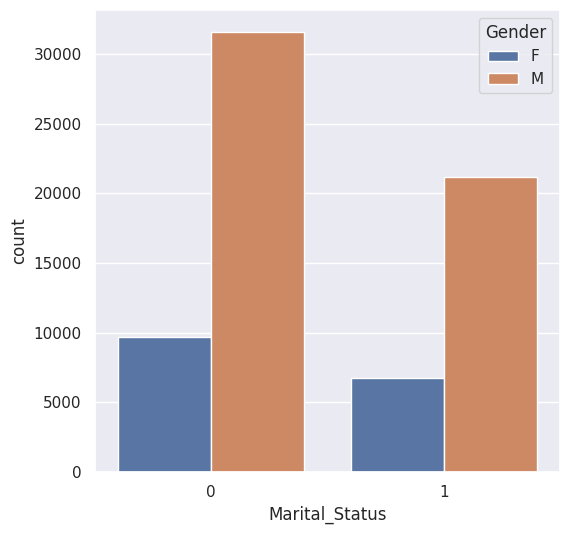

In [37]:
sns.set(rc = {'figure.figsize' : (6,6)})
sns.countplot(x = "Marital_Status", hue = 'Gender', data = df)

<Axes: xlabel='City_Category', ylabel='count'>

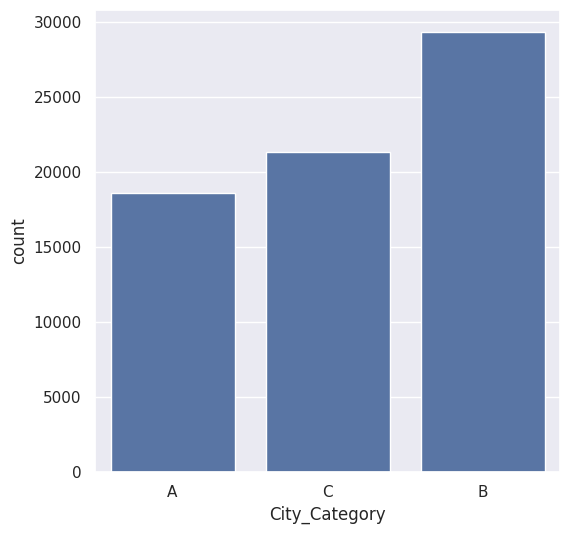

In [38]:
sns.countplot(x = df['City_Category'])

<Axes: xlabel='City_Category', ylabel='count'>

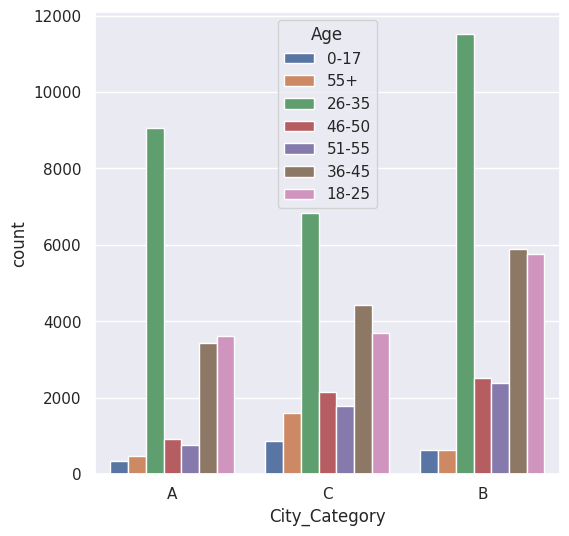

In [39]:
sns.countplot(x = 'City_Category', hue = 'Age', data = df)

<Axes: xlabel='City_Category', ylabel='count'>

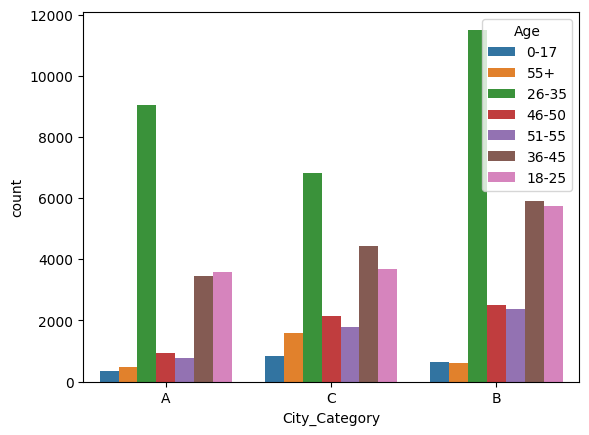

In [35]:
sns.countplot(x = 'City_Category', hue = 'Age', data = df)

<Axes: xlabel='Age', ylabel='count'>

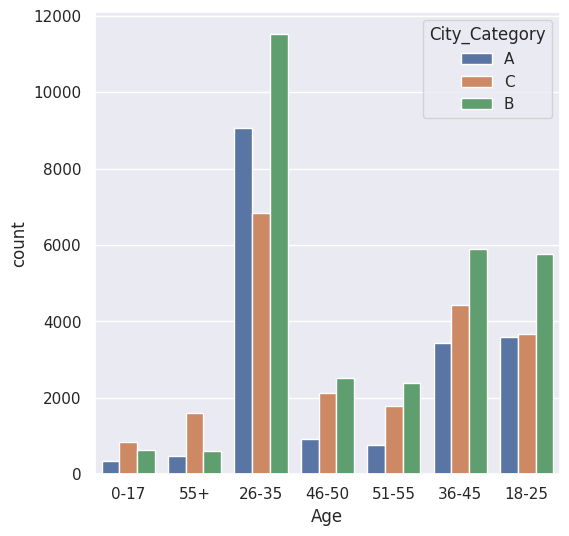

In [40]:
sns.countplot(x = 'Age', hue = 'City_Category', data = df)

<Axes: xlabel='Marital_Status', ylabel='count'>

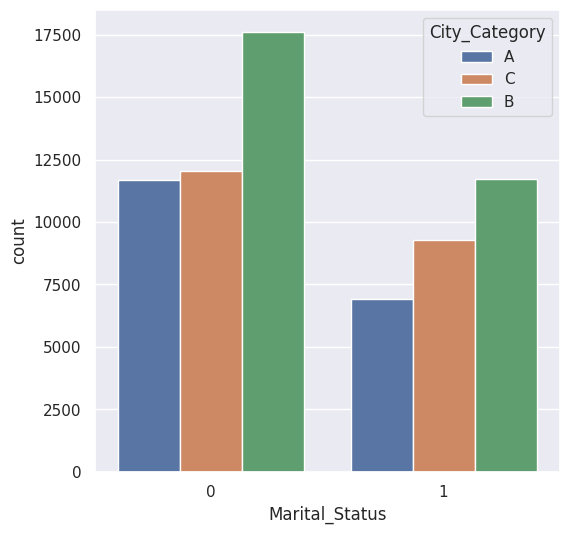

In [41]:
sns.countplot(x = 'Marital_Status', hue = 'City_Category', data = df)

<Axes: >

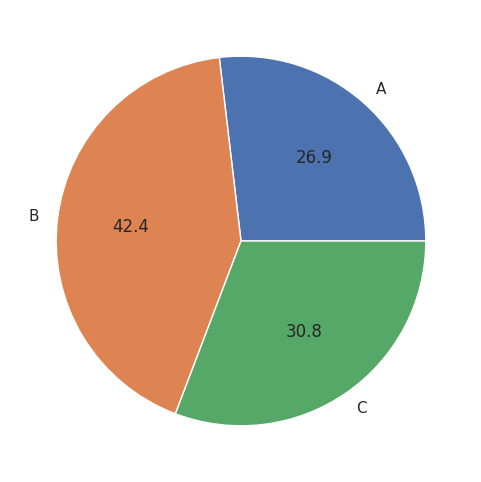

In [42]:
df.groupby('City_Category').size().plot(kind = 'pie', autopct = '%0.1f')

<Axes: xlabel='City_Category', ylabel='count'>

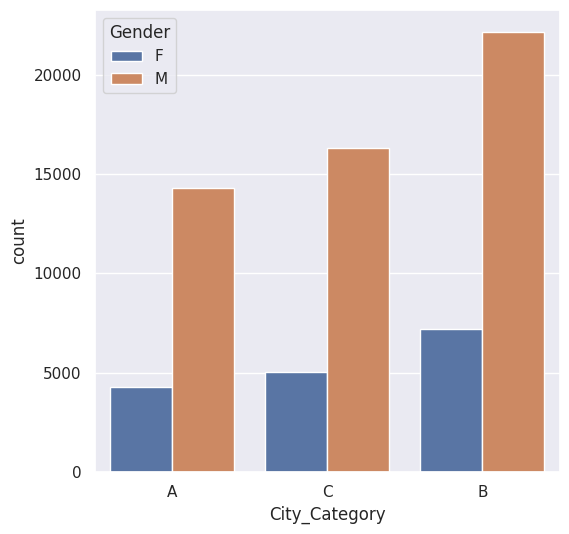

In [43]:
sns.countplot(x = 'City_Category', hue = 'Gender', data = df)

<Axes: ylabel='Purchase'>

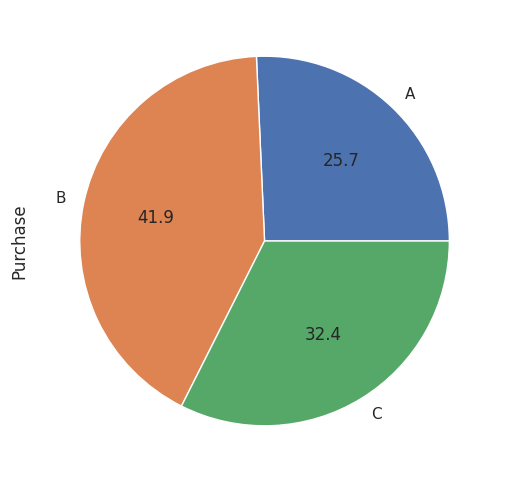

In [44]:
df.groupby('City_Category').sum()['Purchase'].plot(kind = 'pie', autopct = "%0.1f")

<Axes: ylabel='Purchase'>

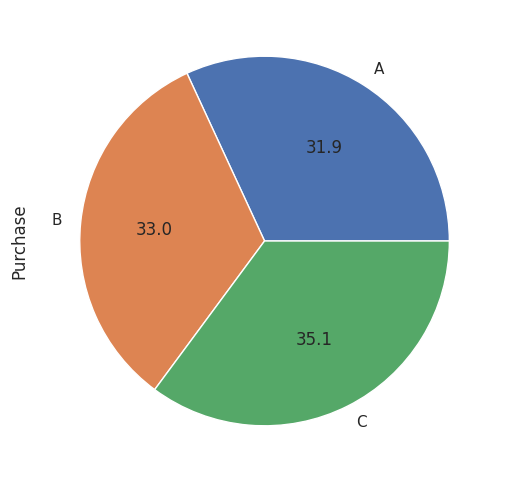

In [46]:
df.groupby('City_Category')['Purchase'].mean().plot(kind = 'pie', autopct = "%0.1f")

OCCUPATION AND CITY

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

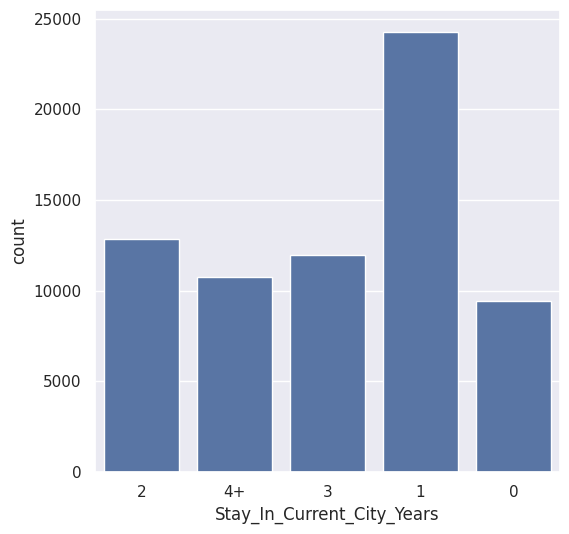

In [47]:
sns.countplot(x = df['Stay_In_Current_City_Years'])

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

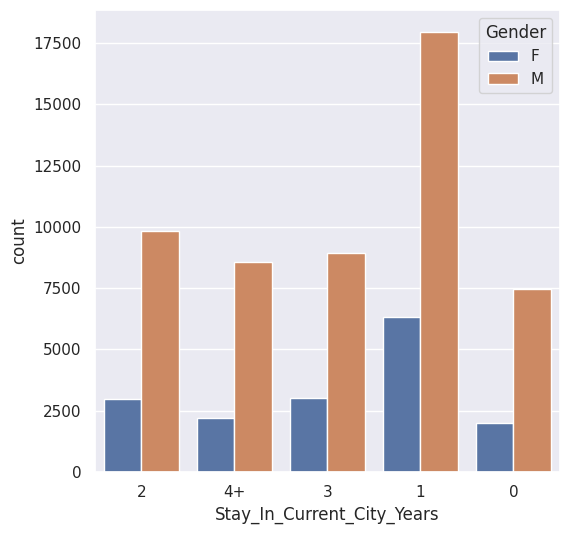

In [48]:
sns.countplot(x = 'Stay_In_Current_City_Years', hue = 'Gender', data = df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

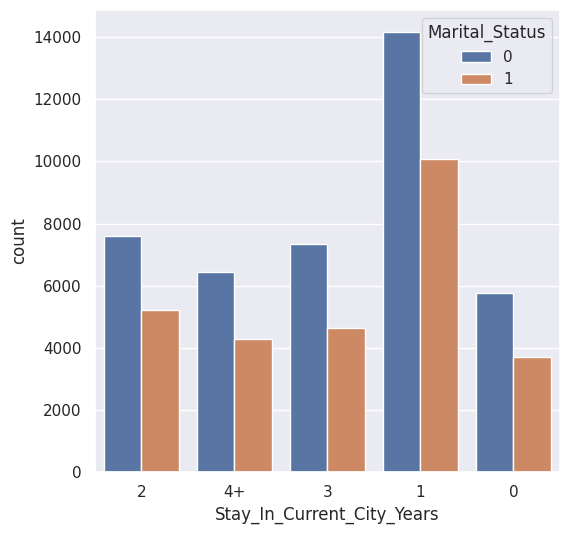

In [49]:
sns.countplot(x = 'Stay_In_Current_City_Years', hue = 'Marital_Status', data = df)

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

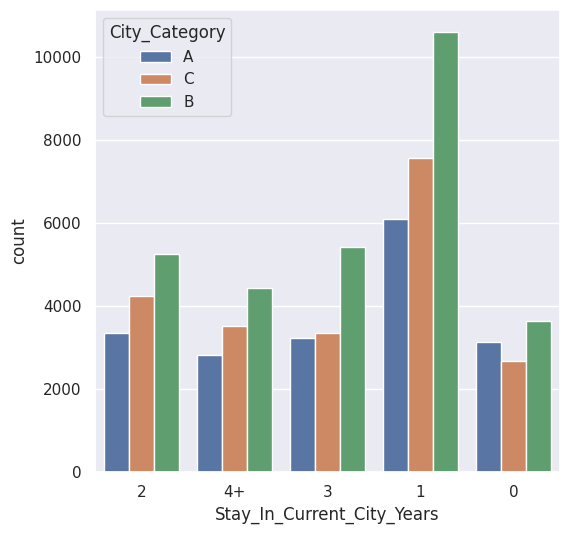

In [50]:
sns.countplot(x = 'Stay_In_Current_City_Years', hue = 'City_Category', data = df)

<Axes: xlabel='City_Category', ylabel='count'>

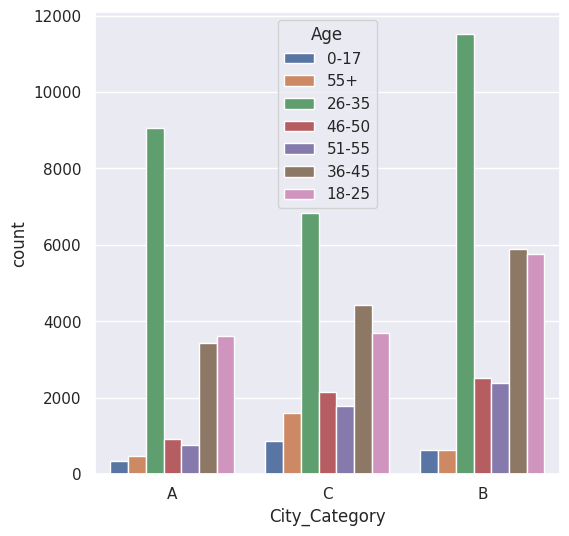

In [51]:
sns.countplot(x = 'City_Category', hue = 'Age',data = df)

<Axes: xlabel='Stay_In_Current_City_Years'>

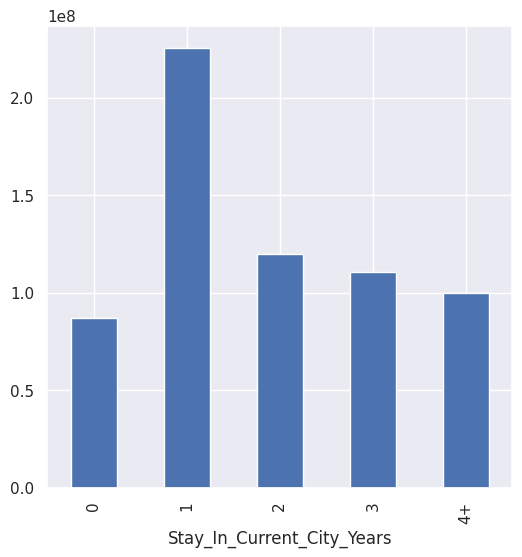

In [52]:
df.groupby('Stay_In_Current_City_Years').sum()['Purchase'].plot(kind = 'bar')


<Axes: xlabel='Stay_In_Current_City_Years'>

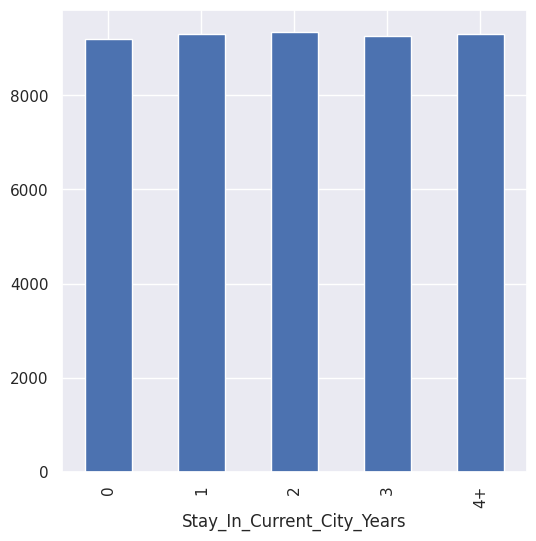

In [54]:
df.groupby('Stay_In_Current_City_Years')['Purchase'].mean().plot(kind = 'bar')

<Axes: xlabel='Occupation', ylabel='count'>

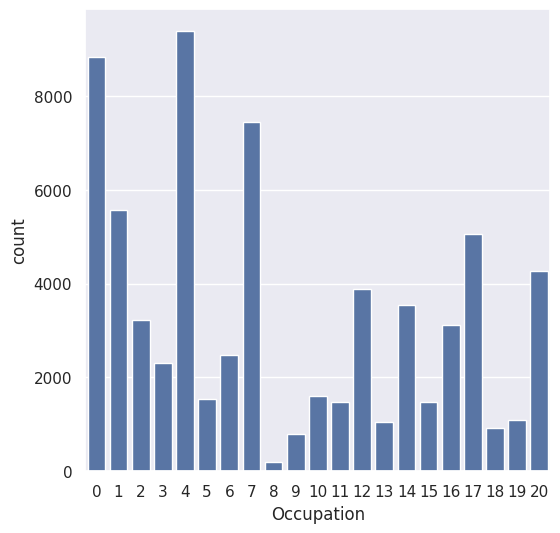

In [55]:
sns.countplot(x = df['Occupation'])

<Axes: xlabel='Occupation'>

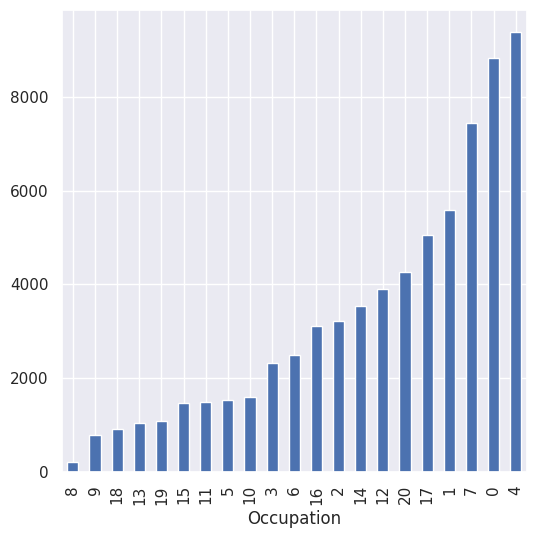

In [56]:
df.groupby('Occupation').size().sort_values().plot(kind = 'bar')

<Axes: xlabel='Occupation'>

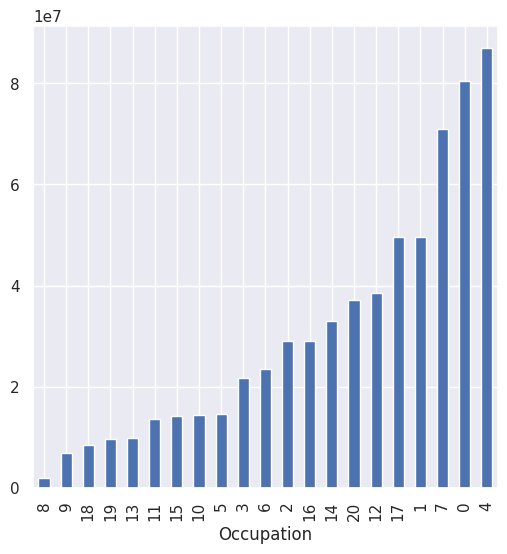

In [57]:
df.groupby('Occupation').sum()['Purchase'].sort_values().plot(kind = 'bar')

<Axes: xlabel='Occupation'>

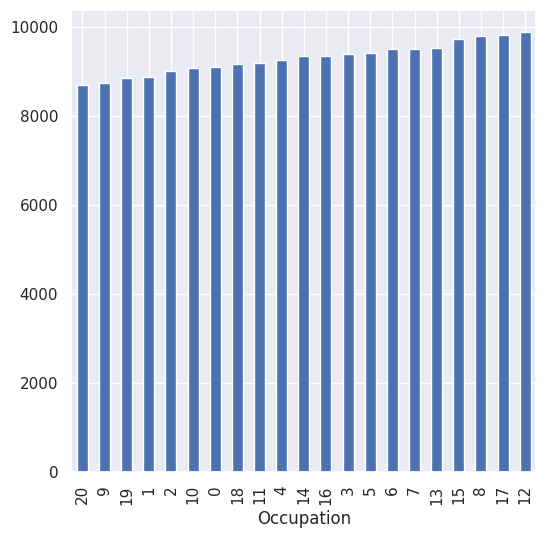

In [59]:
df.groupby('Occupation')['Purchase'].mean().sort_values().plot(kind = 'bar')

<Axes: xlabel='Occupation', ylabel='count'>

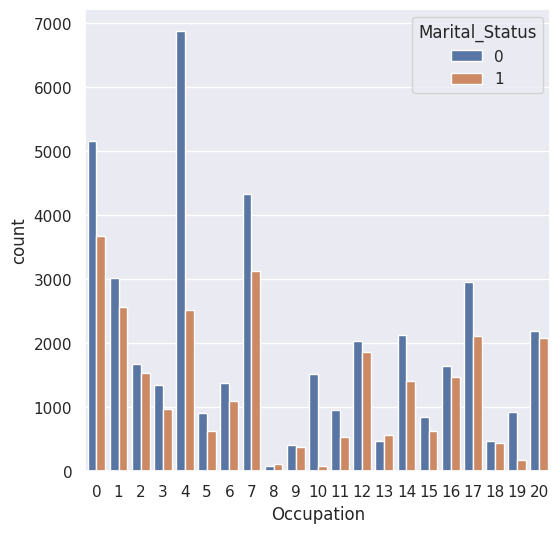

In [60]:
sns.countplot(x = 'Occupation', hue = 'Marital_Status', data = df)


<Axes: xlabel='Occupation', ylabel='count'>

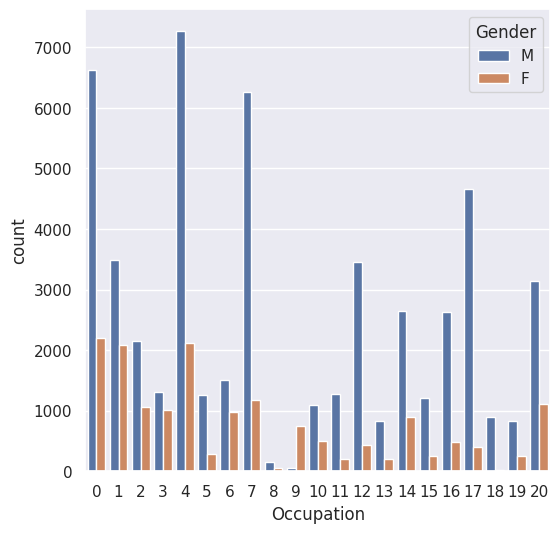

In [61]:
sns.countplot(x = 'Occupation', hue = 'Gender', data = df)

<Axes: xlabel='Occupation'>

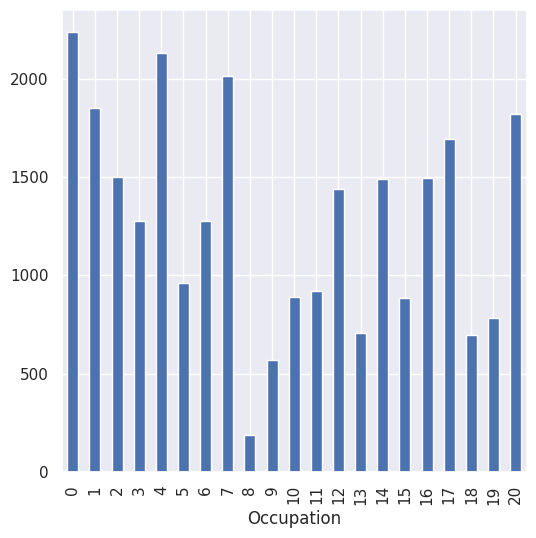

In [62]:
df.groupby('Occupation').nunique()['Product_ID'].plot(kind = 'bar')

<Axes: xlabel='Product_Category_1'>

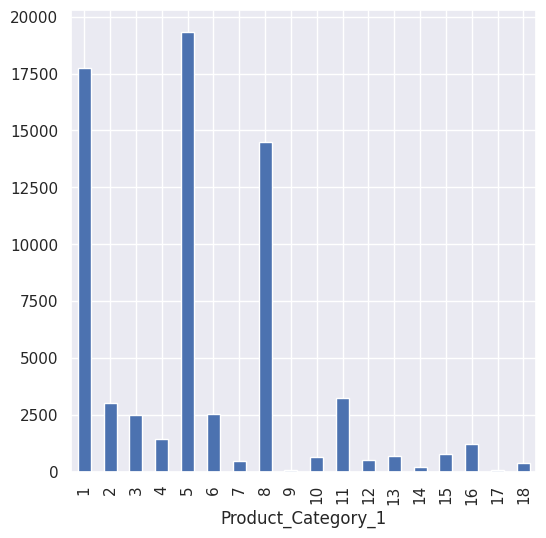

In [63]:
df.groupby('Product_Category_1').size().plot(kind = 'bar')

<Axes: xlabel='Product_Category_1'>

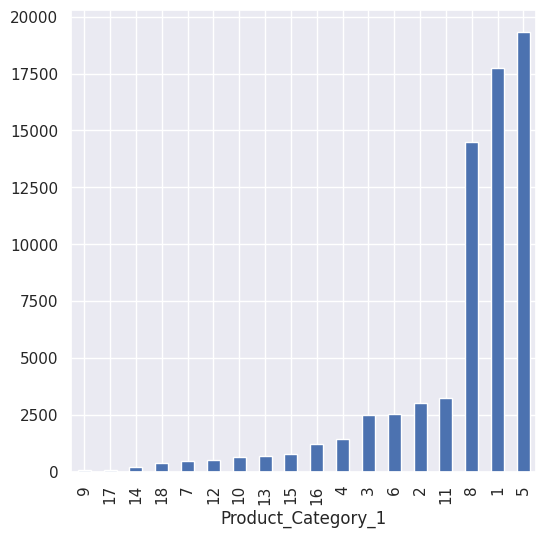

In [64]:
df.groupby('Product_Category_1').size().sort_values().plot(kind = 'bar')

<Axes: xlabel='Product_Category_1'>

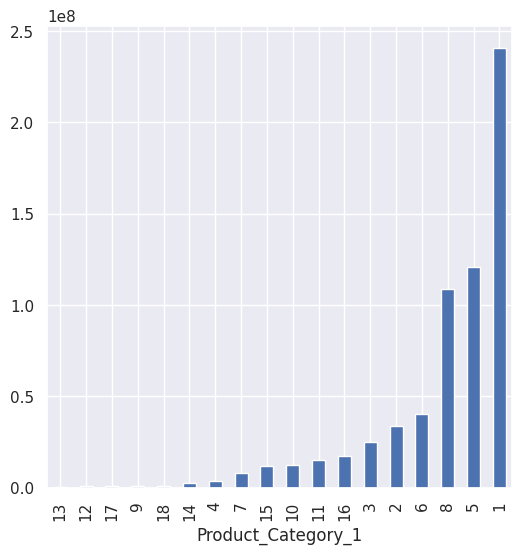

In [65]:
df.groupby('Product_Category_1').sum()['Purchase'].sort_values().plot(kind = 'bar')

<Axes: xlabel='Product_Category_1'>

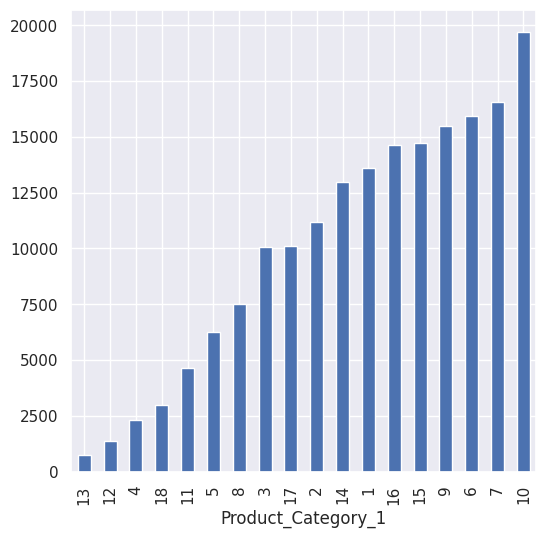

In [67]:
df.groupby('Product_Category_1')['Purchase'].mean().sort_values().plot(kind = 'bar')

<Axes: xlabel='Product_ID'>

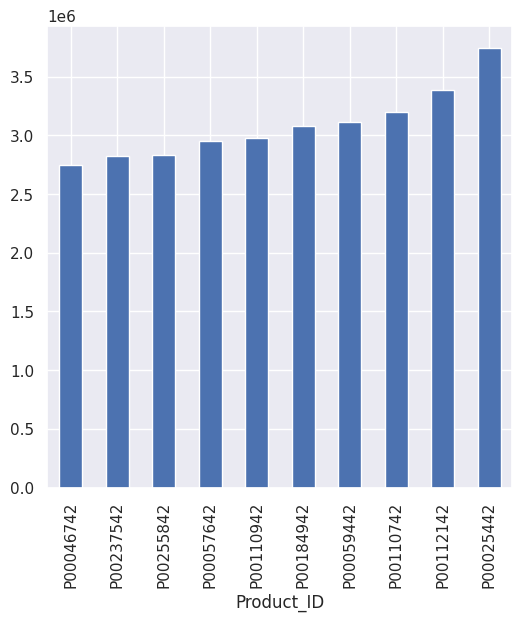

In [68]:
df.groupby('Product_ID').sum()['Purchase'].nlargest(10).sort_values().plot(kind = 'bar')

<Axes: xlabel='Product_ID'>

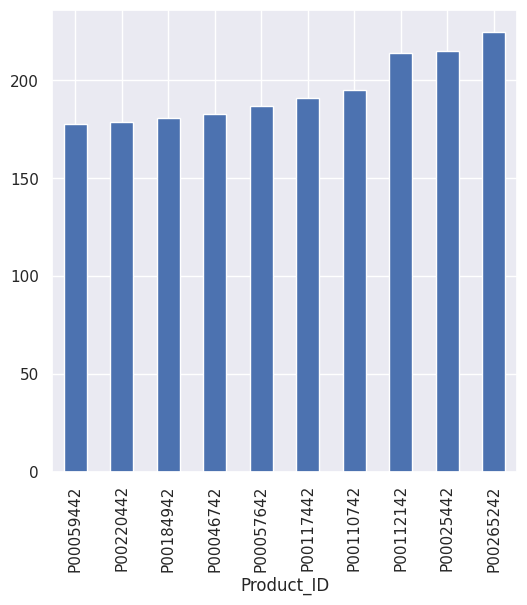

In [69]:
df.groupby('Product_ID').size().nlargest(10).sort_values().plot(kind = 'bar')

<Axes: xlabel='Product_Category_1', ylabel='count'>

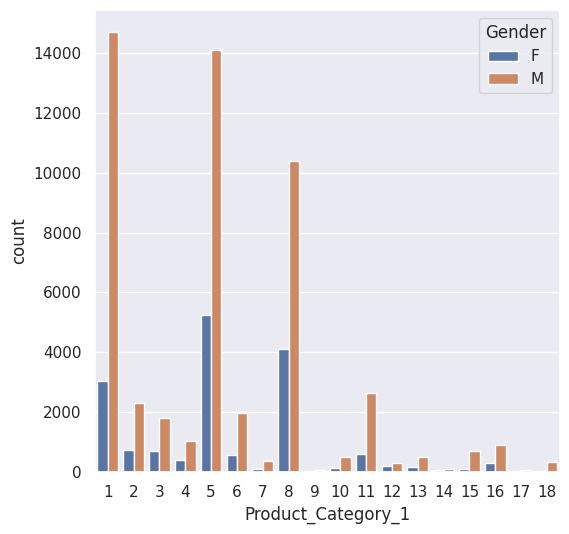

In [70]:
sns.countplot(x = 'Product_Category_1', hue = 'Gender', data = df)

<Axes: xlabel='Product_Category_1', ylabel='count'>

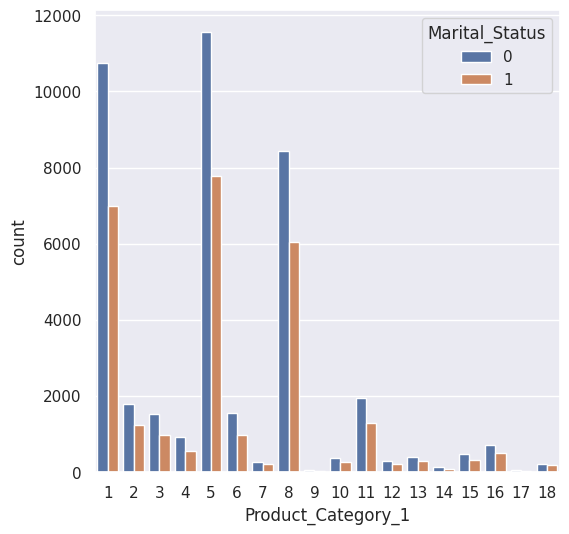

In [71]:
sns.countplot(x = 'Product_Category_1', hue = 'Marital_Status', data = df)

In [72]:
df['MaritalGender'] = (
    df['Gender'] + "_" + df['Marital_Status'].astype(str)
)

In [73]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Purchase,MaritalGender
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370.0,F_0
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200.0,F_0
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422.0,F_0
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057.0,F_0
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969.0,M_0


<Axes: xlabel='MaritalGender', ylabel='count'>

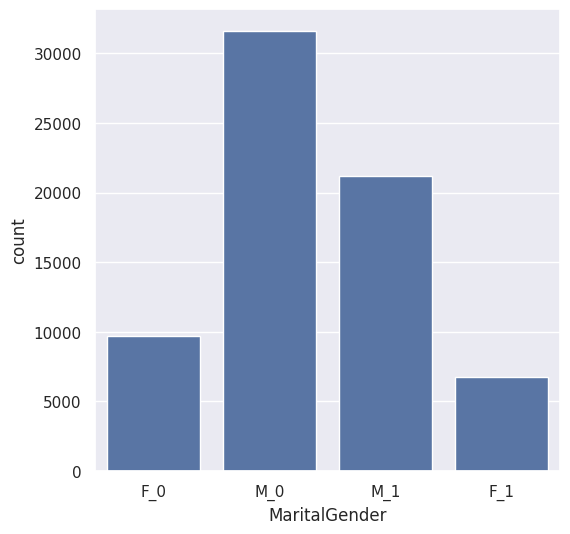

In [74]:
sns.countplot(x = df['MaritalGender'])

<Axes: xlabel='Age', ylabel='count'>

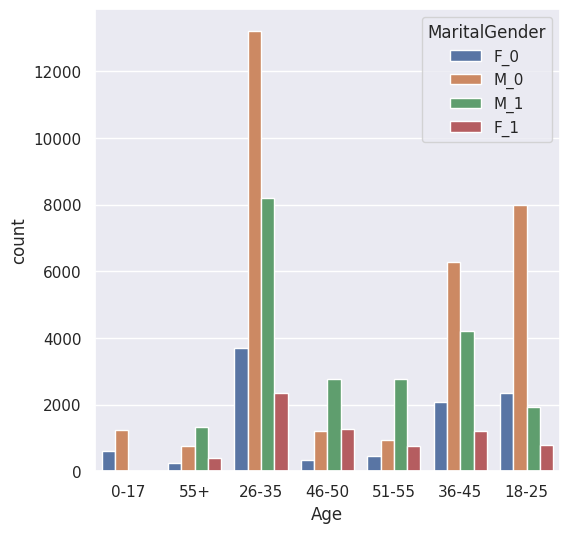

In [75]:
sns.countplot(x = df['Age'], hue = df['MaritalGender'])

<Axes: xlabel='Product_Category_1', ylabel='count'>

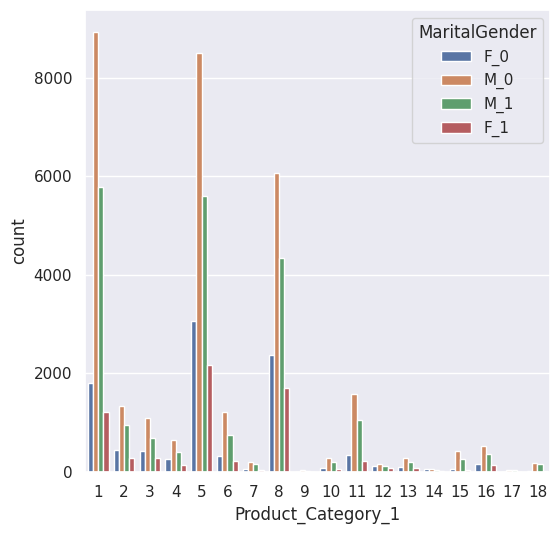

In [76]:
sns.countplot(x = df['Product_Category_1'], hue = df['MaritalGender'])

<Axes: xlabel='Stay_In_Current_City_Years', ylabel='count'>

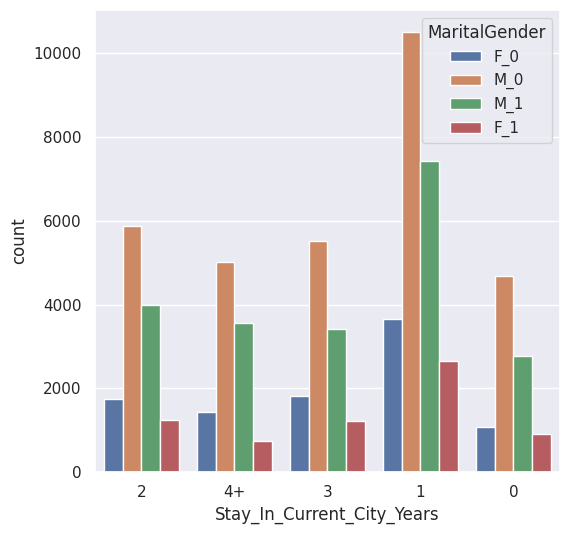

In [77]:
sns.countplot(x = df['Stay_In_Current_City_Years'], hue = df['MaritalGender'])

<Axes: xlabel='City_Category', ylabel='count'>

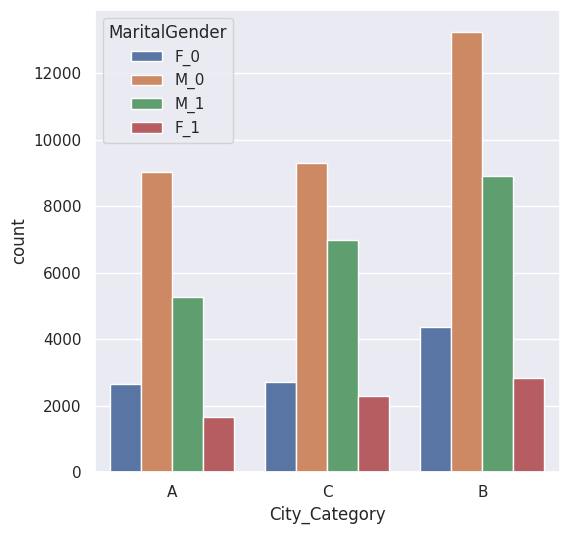

In [78]:
sns.countplot(x = df['City_Category'], hue = df['MaritalGender'])